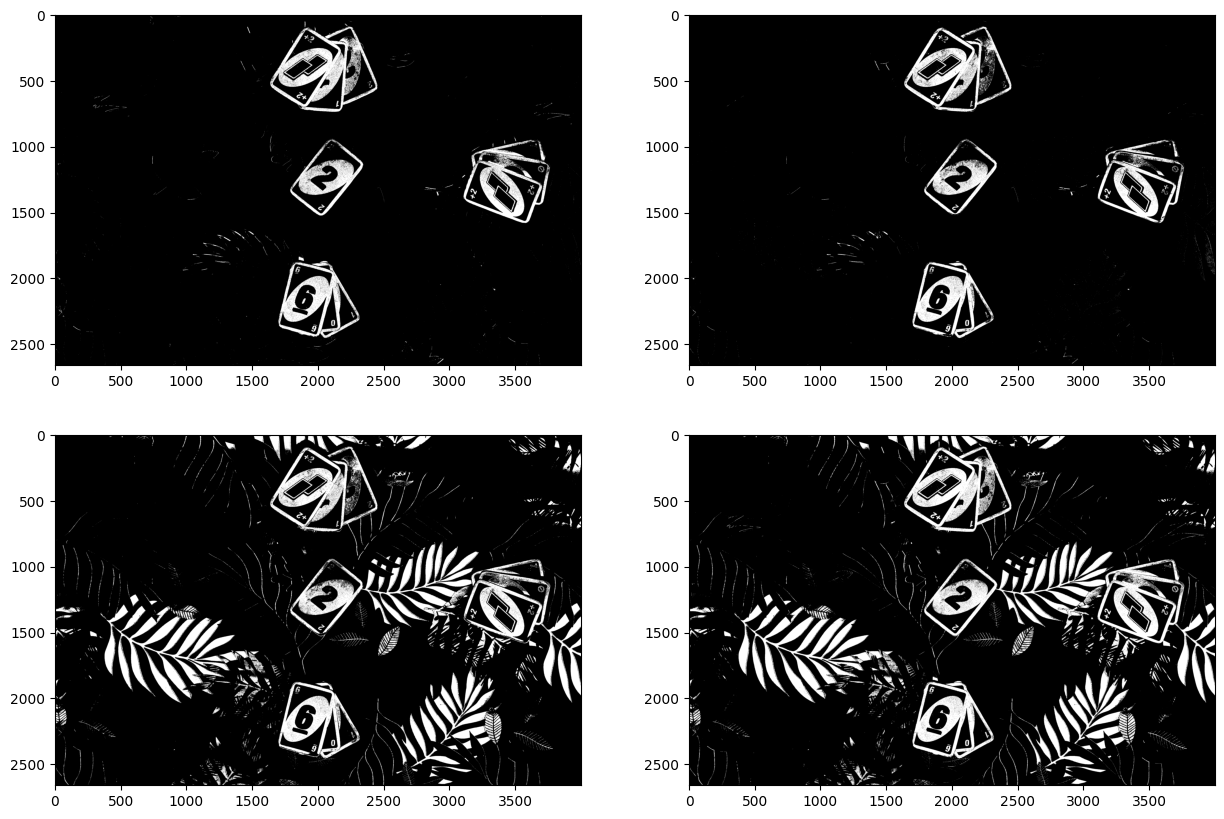

In [31]:
from importlib import reload
from pathlib import Path

import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

import card_detection_helpers as helpers
reload(helpers)
from card_detection_helpers import *
BASE_DIR = Path.cwd().parent
TRAIN_DIR = BASE_DIR / "iapr-26-uno-vision-challenge" / "train_images"

image_paths = sorted(TRAIN_DIR.glob("*.jpg"))


img_color = Image.open(image_paths[70]).convert("RGB")

img_color = np.array(img_color)



lower_white_1 = np.array([10.0, 10, 60.0])
upper_white_1 = np.array([40.0, 100, 100.0])

lower_white_2 = np.array([10, 15, 80])
upper_white_2 = np.array([50, 100.0, 100.0])

lower_white_3 = np.array([10, 15, 85])
upper_white_3 = np.array([360, 100, 100.0])

masks, white_mask = helpers.mask(lower_white_1, upper_white_1, img_color,lower_white_2, upper_white_2, lower_white_3, upper_white_3, n_masks=3)
white_mask_u8 = white_mask.astype(np.uint8) * 255
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1)
plt.imshow(masks[0], cmap="gray")
plt.subplot(2, 2, 2)
plt.imshow(masks[1], cmap="gray")
plt.subplot(2, 2, 3)
plt.imshow(masks[2], cmap="gray")
plt.subplot(2, 2, 4)
plt.imshow(white_mask, cmap="gray") 

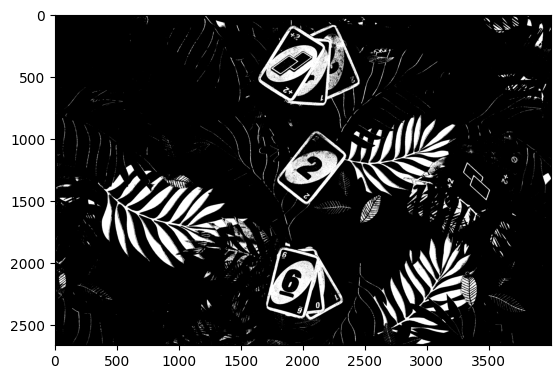

In [32]:
white_mask_no_border=remove_side_white(white_mask)
plt.imshow(white_mask_no_border, cmap="gray")

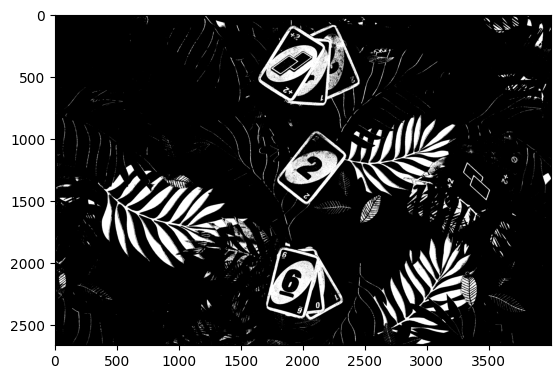

In [33]:
framed_morph_mask = black_contours(white_mask_no_border)
plt.imshow(framed_morph_mask, cmap="gray")

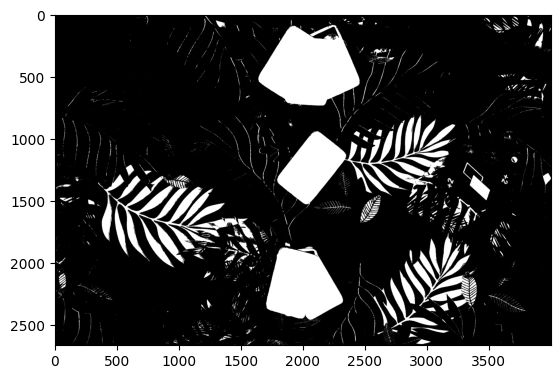

In [34]:
filled_mask = fill_cards(framed_morph_mask)
plt.imshow(filled_mask, cmap="gray")

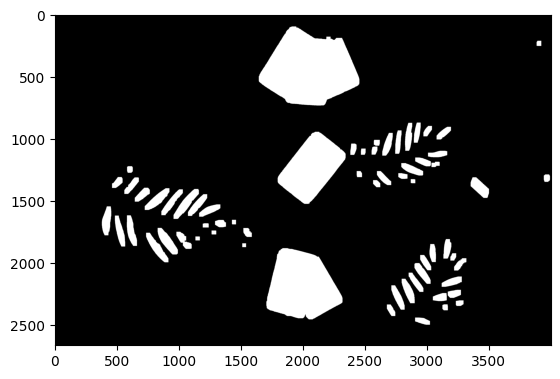

In [35]:
open_frame = open(3,15, filled_mask)
plt.imshow(open_frame, cmap="gray")

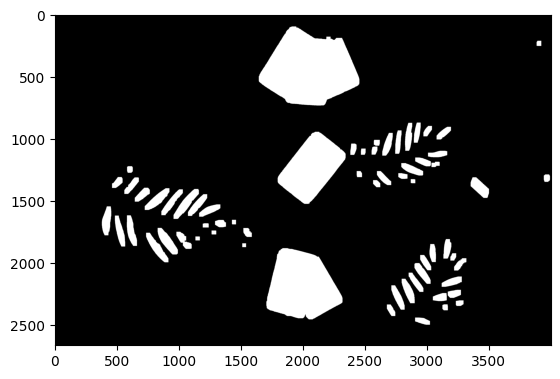

In [36]:
open_frame = open(3,15, filled_mask)
plt.imshow(open_frame, cmap="gray")

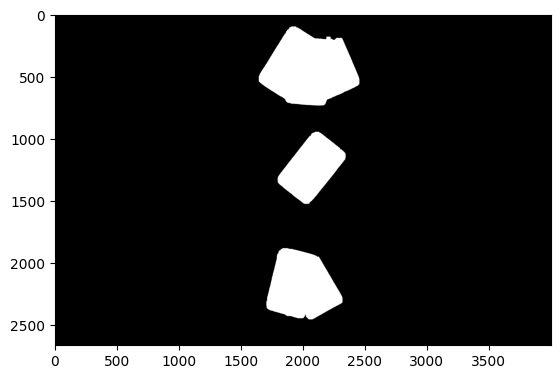

In [37]:
clean_mask = min_area_filter(open_frame, min_area=50000)
plt.imshow(clean_mask, cmap="gray")

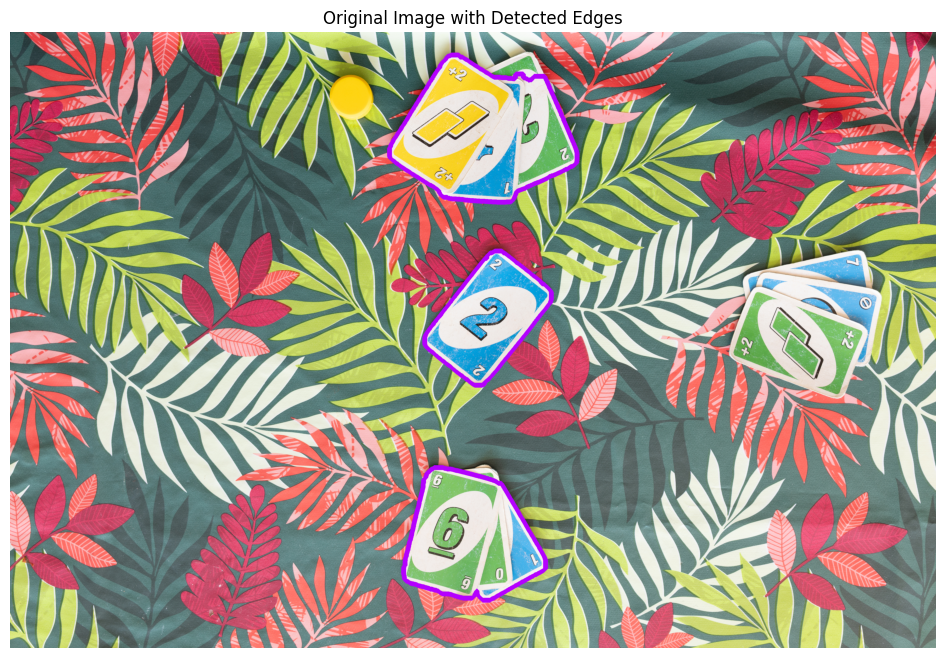

In [38]:
edges = cv2.Canny(clean_mask * 255, 0, 0)
helpers.show_cards_on_frame(img_color, edges)